Loaded samples: (12000, 69)
Epoch 0: Loss=45.6333
Epoch 1: Loss=5.8281
Epoch 2: Loss=6.1211
Epoch 3: Loss=3.7108
Epoch 4: Loss=2.9446
Epoch 5: Loss=2.4259
Epoch 6: Loss=0.8558
Epoch 7: Loss=1.2176
Epoch 8: Loss=1.4192
Epoch 9: Loss=3.8875
Epoch 10: Loss=3.2559
Epoch 11: Loss=1.1236
Epoch 12: Loss=1.4763
Epoch 13: Loss=1.5800
Epoch 14: Loss=2.1255
Epoch 15: Loss=3.1618
Epoch 16: Loss=0.8470
Epoch 17: Loss=1.2165
Epoch 18: Loss=2.4012
Epoch 19: Loss=0.8035

Accuracy: 0.9995833333333334


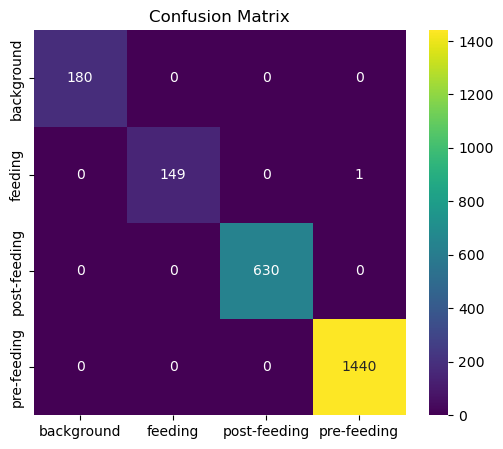


Running SHAP...


  0%|          | 0/50 [00:00<?, ?it/s]

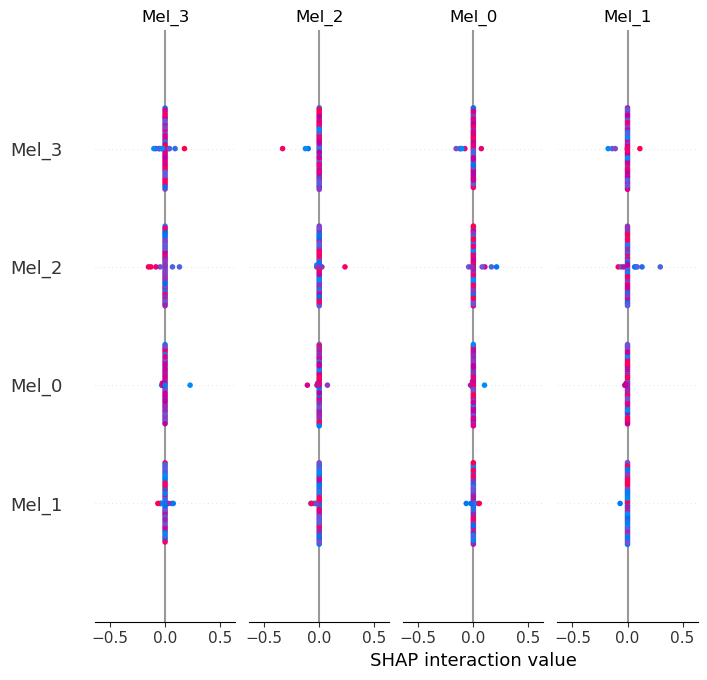

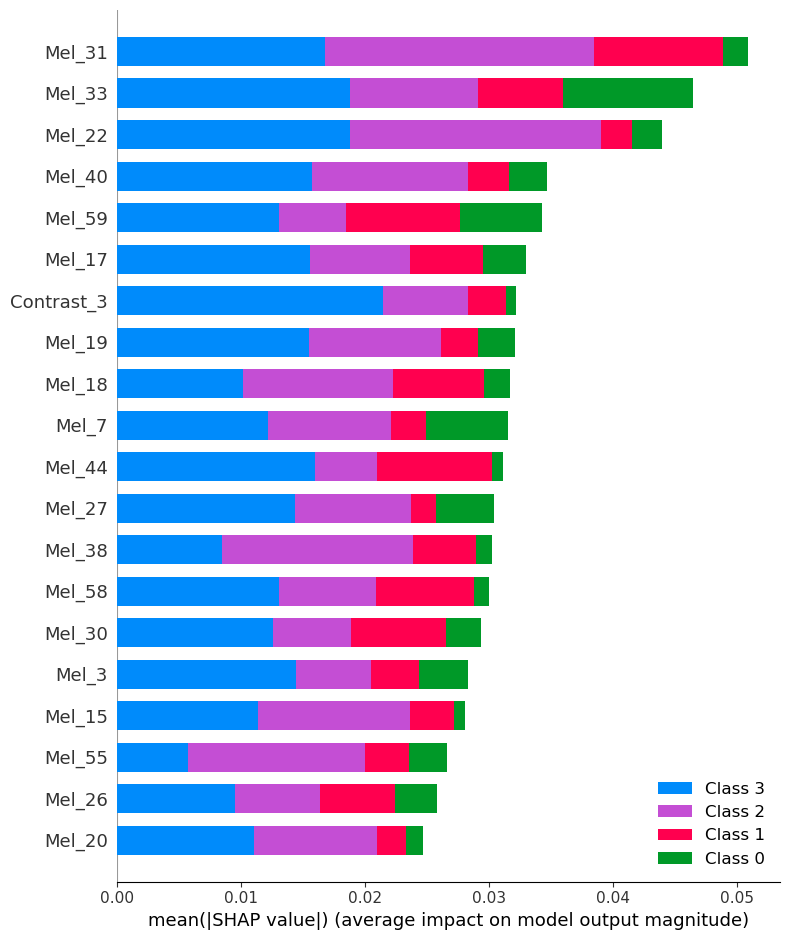

DimensionError: Length of features is not equal to the length of shap_values!

In [1]:
# =========================================================
# FULL PIPELINE + INTERACTION MODEL + SHAP
# =========================================================

import os
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split


# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DATASET_PATH = "/home/feliciano/Documents/DATASET_SEABREAM_SEGMENTED/Segmented_2s"
SAMPLE_RATE = 8000
N_MELS = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ---------------------------------------------------------
# FEATURE EXTRACTION
# ---------------------------------------------------------
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, fmax=1000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    contrast = librosa.feature.spectral_contrast(
        y=y, sr=sr, fmin=50, n_bands=4
    )

    mel_feat = np.mean(mel_db, axis=1)
    contrast_feat = np.mean(contrast, axis=1)

    return np.concatenate([mel_feat, contrast_feat])


# ---------------------------------------------------------
# LABEL MAPPING
# ---------------------------------------------------------
def map_label_from_path(path):
    p = path.lower()

    if "background" in p: return "background"
    if "pre" in p and "feed" in p: return "pre-feeding"
    if "post" in p and "feed" in p: return "post-feeding"
    if "feeding" in p: return "feeding"

    return None


# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
X, y = [], []

for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            label = map_label_from_path(root)
            if label is None:
                continue

            X.append(extract_features(os.path.join(root, file)))
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Loaded samples:", X.shape)


# ---------------------------------------------------------
# PREPROCESS
# ---------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_train_t = torch.tensor(y_train).to(DEVICE)
y_test_t = torch.tensor(y_test).to(DEVICE)


# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------
class InteractionModel(nn.Module):
    def __init__(self, dim, num_classes, k=32):
        super().__init__()
        self.query = nn.Linear(dim, k)
        self.key = nn.Linear(dim, k)

        self.classifier = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)

        scores = Q @ K.T / np.sqrt(Q.shape[1])
        A = torch.softmax(scores, dim=1)

        y = A @ x
        y = y + x

        return self.classifier(y)


model = InteractionModel(X_train.shape[1], len(np.unique(y))).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# ---------------------------------------------------------
# TRAIN
# ---------------------------------------------------------
epochs = 20
batch_size = 32

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_t.size(0))
    total_loss = 0

    for i in range(0, X_train_t.size(0), batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train_t[idx]
        yb = y_train_t[idx]

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: Loss={total_loss:.4f}")


# ---------------------------------------------------------
# EVALUATE
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1).cpu().numpy()
    probs_np = probs.cpu().numpy()

y_true = y_test

print("\nAccuracy:", accuracy_score(y_true, preds))


# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------
cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.show()


# =========================================================
# ✅ ✅ SHAP SECTION
# =========================================================

print("\nRunning SHAP...")

model_cpu = model.to("cpu")
model_cpu.eval()

X_train_np = X_train.copy()
X_test_np = X_test.copy()

# subset (important)
background = X_train_np[np.random.choice(X_train_np.shape[0], 100, replace=False)]
test_samples = X_test_np[:50]


# ---------------------------------------------------------
# MODEL WRAPPER
# ---------------------------------------------------------
def model_predict(x):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        out = model_cpu(x_tensor)
        return torch.softmax(out, dim=1).numpy()


# ---------------------------------------------------------
# SHAP EXPLAINER
# ---------------------------------------------------------
explainer = shap.KernelExplainer(model_predict, background)

shap_values = explainer.shap_values(test_samples, nsamples=100)


# ---------------------------------------------------------
# FEATURE NAMES
# ---------------------------------------------------------
n_mel = N_MELS
n_contrast = test_samples.shape[1] - n_mel

feature_names = (
    [f"Mel_{i}" for i in range(n_mel)] +
    [f"Contrast_{i}" for i in range(n_contrast)]
)


# ---------------------------------------------------------
# SUMMARY PLOT
# ---------------------------------------------------------
shap.summary_plot(shap_values, test_samples, feature_names=feature_names)


# ---------------------------------------------------------
# BAR PLOT
# ---------------------------------------------------------
shap.summary_plot(shap_values, test_samples,
                  feature_names=feature_names,
                  plot_type="bar")


# ---------------------------------------------------------
# FORCE PLOT
# ---------------------------------------------------------
shap.force_plot(
    explainer.expected_value[0],
    shap_values[0][0],
    test_samples[0],
    feature_names=feature_names,
    matplotlib=True
)


# ---------------------------------------------------------
# FREQUENCY IMPORTANCE (CRITICAL)
# ---------------------------------------------------------
mean_shap = np.mean(np.abs(shap_values[0]), axis=0)

plt.figure(figsize=(10,5))
plt.plot(mean_shap[:N_MELS])
plt.title("SHAP Importance - Mel Bands")
plt.xlabel("Mel Band Index")
plt.ylabel("Importance")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.bar(range(n_contrast), mean_shap[N_MELS:])
plt.title("SHAP Importance - Spectral Contrast")
plt.xlabel("Contrast Band")
plt.ylabel("Importance")
plt.show()

Loaded samples: (12000, 69)
Epoch 0: Loss = 46.8780
Epoch 1: Loss = 6.3386
Epoch 2: Loss = 2.6763
Epoch 3: Loss = 2.3726
Epoch 4: Loss = 5.4659
Epoch 5: Loss = 5.3680
Epoch 6: Loss = 1.3872
Epoch 7: Loss = 1.3097
Epoch 8: Loss = 0.8613
Epoch 9: Loss = 0.3852
Epoch 10: Loss = 1.6013
Epoch 11: Loss = 0.2890
Epoch 12: Loss = 0.6510
Epoch 13: Loss = 2.1036
Epoch 14: Loss = 2.5031
Epoch 15: Loss = 1.5563
Epoch 16: Loss = 0.5613
Epoch 17: Loss = 2.1851
Epoch 18: Loss = 6.3848
Epoch 19: Loss = 0.8256

Accuracy: 0.9995833333333334
Precision: 0.9998265093684942
Recall: 0.9983333333333333
F1: 0.9990771041734625


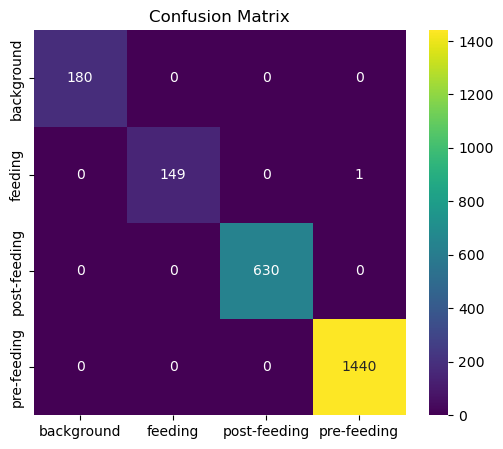


Running SHAP...


  0%|          | 0/50 [00:00<?, ?it/s]

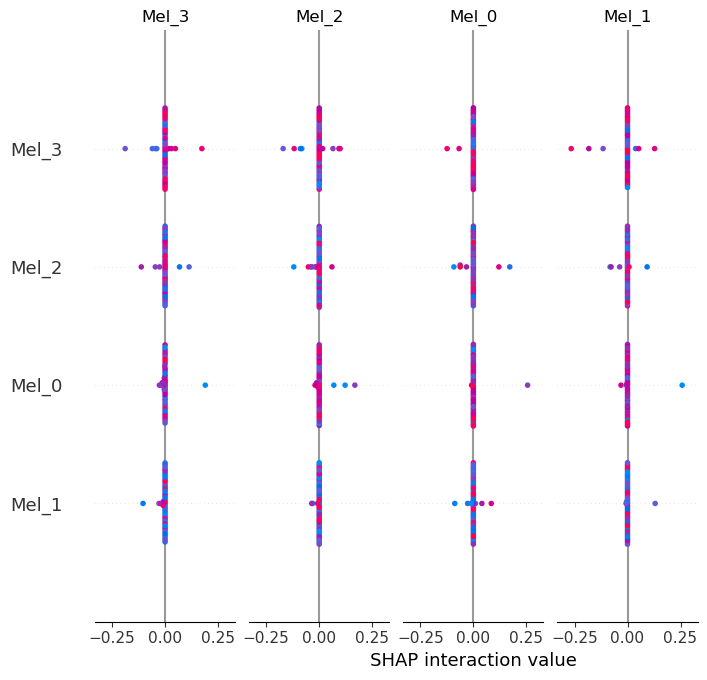

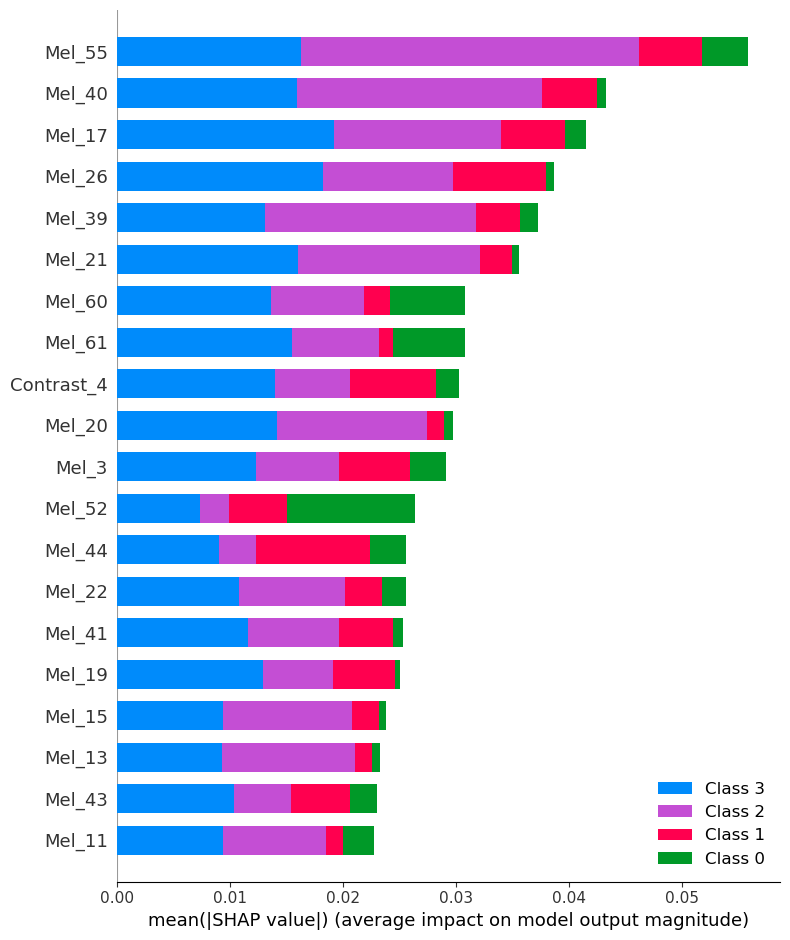

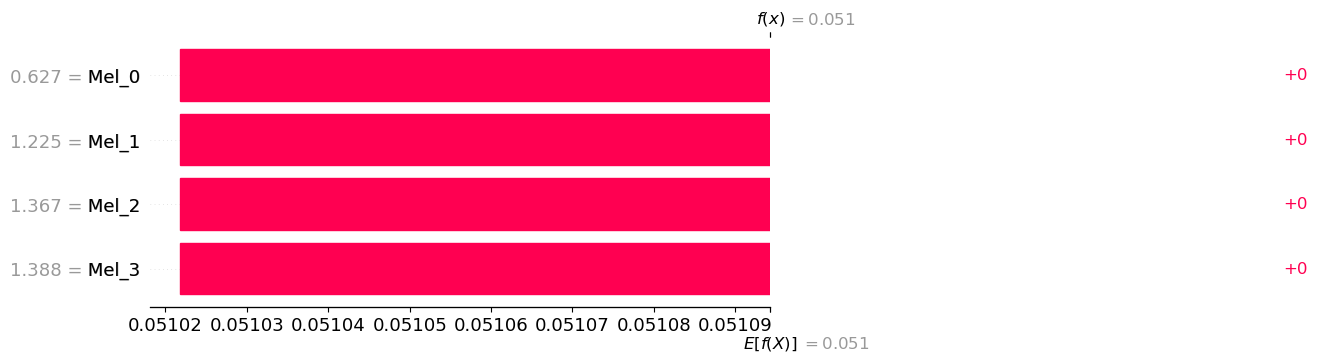

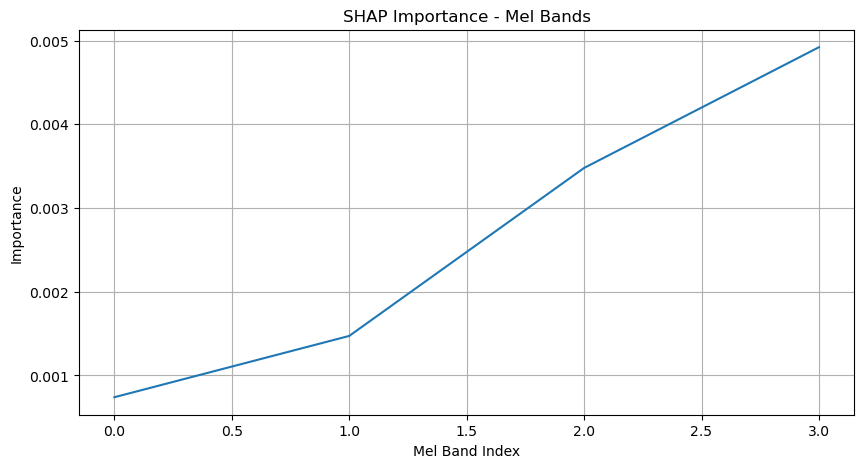

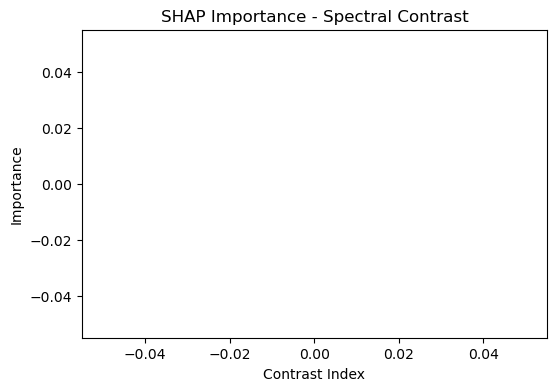

In [3]:
# =========================================================
# COMPLETE PIPELINE + INTERACTION MODEL + SHAP (FINAL)
# =========================================================

import os
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split


# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DATASET_PATH = "/home/feliciano/Documents/DATASET_SEABREAM_SEGMENTED/Segmented_2s"
SAMPLE_RATE = 8000
N_MELS = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ---------------------------------------------------------
# FEATURE EXTRACTION
# ---------------------------------------------------------
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, fmax=1000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    contrast = librosa.feature.spectral_contrast(
        y=y, sr=sr, fmin=50, n_bands=4
    )

    mel_feat = np.mean(mel_db, axis=1)
    contrast_feat = np.mean(contrast, axis=1)

    return np.concatenate([mel_feat, contrast_feat])


# ---------------------------------------------------------
# LABEL MAPPING
# ---------------------------------------------------------
def map_label_from_path(path):
    p = path.lower()
    if "background" in p: return "background"
    if "pre" in p and "feed" in p: return "pre-feeding"
    if "post" in p and "feed" in p: return "post-feeding"
    if "feeding" in p: return "feeding"
    return None


# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
X, y = [], []

for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            label = map_label_from_path(root)
            if label is None:
                continue

            X.append(extract_features(os.path.join(root, file)))
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Loaded samples:", X.shape)


# ---------------------------------------------------------
# PREPROCESS
# ---------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_train_t = torch.tensor(y_train).to(DEVICE)
y_test_t = torch.tensor(y_test).to(DEVICE)


# ---------------------------------------------------------
# MODEL
# ---------------------------------------------------------
class InteractionModel(nn.Module):
    def __init__(self, dim, num_classes, k=32):
        super().__init__()
        self.query = nn.Linear(dim, k)
        self.key = nn.Linear(dim, k)

        self.classifier = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)

        scores = Q @ K.T / np.sqrt(Q.shape[1])
        A = torch.softmax(scores, dim=1)

        y = A @ x + x
        return self.classifier(y)


model = InteractionModel(X_train.shape[1], len(np.unique(y))).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


# ---------------------------------------------------------
# TRAIN
# ---------------------------------------------------------
epochs = 20
batch_size = 32

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_t.size(0))
    total_loss = 0

    for i in range(0, X_train_t.size(0), batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train_t[idx]
        yb = y_train_t[idx]

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: Loss = {total_loss:.4f}")


# ---------------------------------------------------------
# EVALUATE
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1).cpu().numpy()

y_true = y_test

print("\nAccuracy:", accuracy_score(y_true, preds))
print("Precision:", precision_score(y_true, preds, average="macro"))
print("Recall:", recall_score(y_true, preds, average="macro"))
print("F1:", f1_score(y_true, preds, average="macro"))


# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------
cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.show()


# =========================================================
# ✅ ✅ SHAP (FINAL STABLE VERSION)
# =========================================================

print("\nRunning SHAP...")

model_cpu = model.to("cpu")
model_cpu.eval()

X_train_np = X_train.copy()
X_test_np = X_test.copy()

background = X_train_np[np.random.choice(X_train_np.shape[0], 100, replace=False)]
test_samples = X_test_np[:50]


def model_predict(x):
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        out = model_cpu(x_tensor)
        return torch.softmax(out, dim=1).numpy()


explainer = shap.KernelExplainer(model_predict, background)

shap_values = explainer.shap_values(test_samples, nsamples=100)


# ---------------------------------------------------------
# FEATURE NAMES
# ---------------------------------------------------------
feature_names = (
    [f"Mel_{i}" for i in range(N_MELS)] +
    [f"Contrast_{i}" for i in range(test_samples.shape[1] - N_MELS)]
)


# ---------------------------------------------------------
# GLOBAL EXPLANATION
# ---------------------------------------------------------
shap.summary_plot(shap_values, test_samples, feature_names=feature_names)

shap.summary_plot(
    shap_values,
    test_samples,
    feature_names=feature_names,
    plot_type="bar"
)


# ---------------------------------------------------------
# ✅ LOCAL EXPLANATION (SAFE – NO ERRORS)
# ---------------------------------------------------------

# choose class 0 for explanation
if isinstance(shap_values, list):
    sv = shap_values[0]
    base_val = explainer.expected_value[0]
else:
    sv = shap_values[0]
    base_val = explainer.expected_value[0]

sample_idx = 0

explanation = shap.Explanation(
    values=sv[sample_idx],
    base_values=base_val,
    data=test_samples[sample_idx],
    feature_names=feature_names
)

# ✅ SAFE replacement for force_plot
shap.plots.waterfall(explanation, max_display=15)


# ---------------------------------------------------------
# FREQUENCY IMPORTANCE
# ---------------------------------------------------------
mean_shap = np.mean(np.abs(sv), axis=0)

plt.figure(figsize=(10, 5))
plt.plot(mean_shap[:N_MELS])
plt.title("SHAP Importance - Mel Bands")
plt.xlabel("Mel Band Index")
plt.ylabel("Importance")
plt.grid()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(range(len(mean_shap) - N_MELS), mean_shap[N_MELS:])
plt.title("SHAP Importance - Spectral Contrast")
plt.xlabel("Contrast Index")
plt.ylabel("Importance")
plt.show()

Total files: 12000
Feature shape: (9600, 133)
Epoch 0: Loss=43.1639
Epoch 1: Loss=0.9230
Epoch 2: Loss=1.0360
Epoch 3: Loss=0.3444
Epoch 4: Loss=0.1580
Epoch 5: Loss=0.0337
Epoch 6: Loss=0.0193
Epoch 7: Loss=0.0141
Epoch 8: Loss=0.0108
Epoch 9: Loss=0.0084
Epoch 10: Loss=0.0067
Epoch 11: Loss=0.0054
Epoch 12: Loss=0.0044
Epoch 13: Loss=0.0036
Epoch 14: Loss=0.0029

Accuracy: 0.99875
F1: 0.9972640642583549


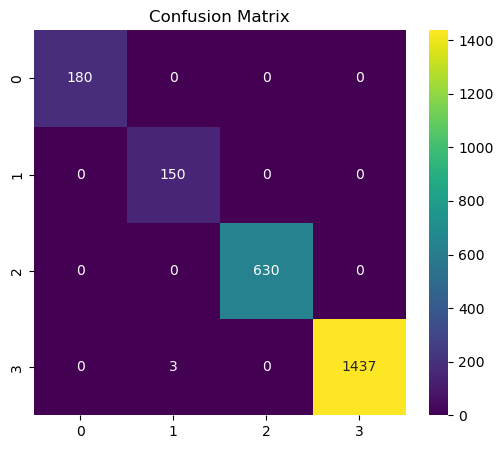


Running SHAP...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/feliciano/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=2.876e-02, with an active set of 1 regressors, and the smallest cholesky pivot element being 5.960e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/feliciano/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=4.357e-02, with an active set of 5 regressors, and the smallest cholesky pivot element being 4.215e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(


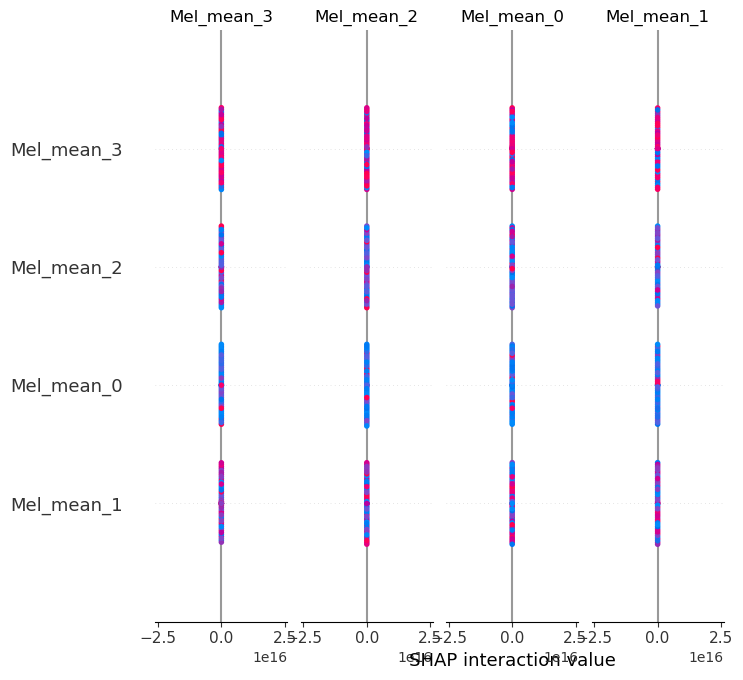

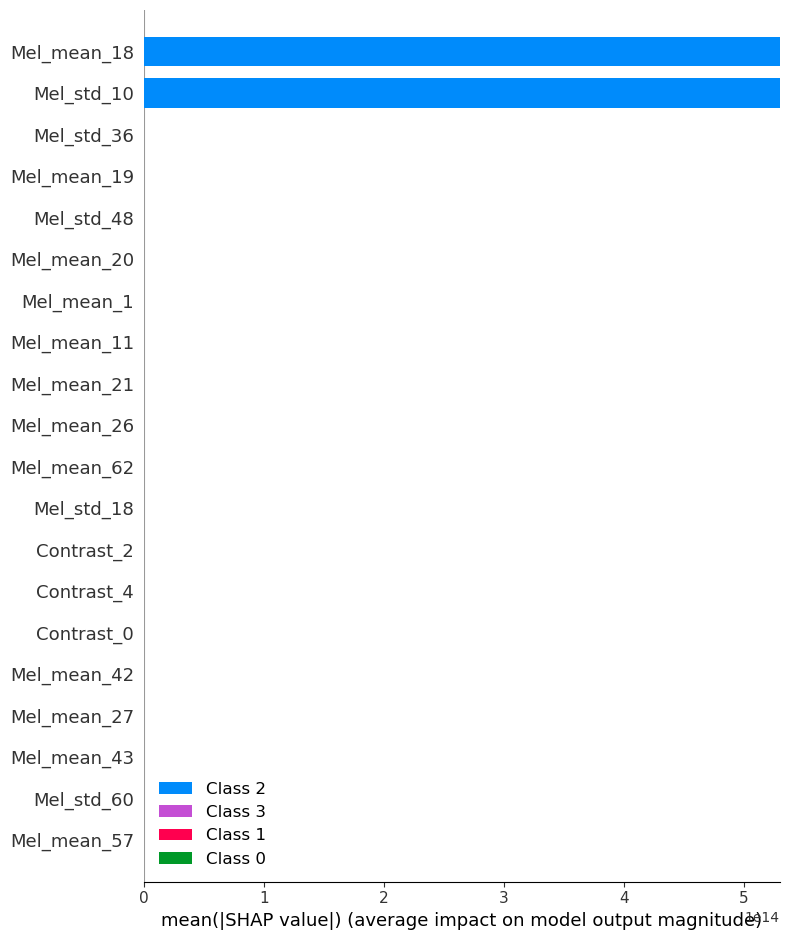

In [4]:
# =========================================================
# FULL CORRECTED PIPELINE (ALL FIXES APPLIED)
# =========================================================

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DATASET_PATH = "/home/feliciano/Documents/DATASET_SEABREAM_SEGMENTED/Segmented_2s"
SAMPLE_RATE = 8000
N_MELS = 64
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =========================================================
# STEP 1: LOAD FILES (NO LEAKAGE)
# =========================================================
file_paths, labels = [], []

def map_label_from_path(path):
    p = path.lower()
    if "background" in p: return "background"
    if "pre" in p and "feed" in p: return "pre-feeding"
    if "post" in p and "feed" in p: return "post-feeding"
    if "feeding" in p: return "feeding"
    return None


for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            label = map_label_from_path(root)
            if label:
                file_paths.append(os.path.join(root, file))
                labels.append(label)

file_paths = np.array(file_paths)
labels = np.array(labels)

print("Total files:", len(file_paths))


# =========================================================
# STEP 2: SPLIT BEFORE FEATURES
# =========================================================
train_paths, test_paths, y_train_raw, y_test_raw = train_test_split(
    file_paths, labels, test_size=0.2, stratify=labels, random_state=42
)


# =========================================================
# STEP 3: FEATURE EXTRACTION
# =========================================================
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, fmax=1000)
    mel_db = librosa.power_to_db(mel)

    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=50, n_bands=4)

    mel_mean = np.mean(mel_db, axis=1)
    mel_std  = np.std(mel_db, axis=1)
    contrast_mean = np.mean(contrast, axis=1)

    return np.concatenate([mel_mean, mel_std, contrast_mean])


def build_dataset(paths):
    return np.array([extract_features(p) for p in paths])


X_train = build_dataset(train_paths)
X_test  = build_dataset(test_paths)

print("Feature shape:", X_train.shape)


# =========================================================
# STEP 4: PREPROCESS
# =========================================================
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
X_test_t  = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_train_t = torch.tensor(y_train).to(DEVICE)


# =========================================================
# ✅ FIXED INTERACTION MODEL
# =========================================================
class InteractionModel(nn.Module):
    def __init__(self, dim, num_classes, k=32):
        super().__init__()

        self.query = nn.Linear(dim, k)
        self.key   = nn.Linear(dim, k)
        self.value = nn.Linear(k, dim)   # ✅ FIX

        self.classifier = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)

        scores = Q * K
        A = torch.softmax(scores, dim=1)

        y = self.value(A)   # ✅ FIX
        y = y + x

        return self.classifier(y)


model = InteractionModel(X_train.shape[1], len(np.unique(y_train))).to(DEVICE)


# =========================================================
# TRAIN
# =========================================================
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

batch_size = 32

for epoch in range(15):
    model.train()
    perm = torch.randperm(X_train_t.shape[0])
    total_loss = 0

    for i in range(0, X_train_t.shape[0], batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train_t[idx]
        yb = y_train_t[idx]

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: Loss={total_loss:.4f}")


# =========================================================
# EVALUATION
# =========================================================
model.eval()
with torch.no_grad():
    preds = torch.argmax(model(X_test_t), dim=1).cpu().numpy()

print("\nAccuracy:", accuracy_score(y_test, preds))
print("F1:", f1_score(y_test, preds, average="macro"))


# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")
plt.title("Confusion Matrix")
plt.show()


# =========================================================
# SHAP
# =========================================================
print("\nRunning SHAP...")

model_cpu = model.to("cpu")
model_cpu.eval()

background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
test_samples = X_test[:50]

def predict_fn(x):
    x_t = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        return torch.softmax(model_cpu(x_t), dim=1).numpy()

explainer = shap.KernelExplainer(predict_fn, background)
shap_values = explainer.shap_values(test_samples, nsamples=100)


feature_names = (
    [f"Mel_mean_{i}" for i in range(N_MELS)] +
    [f"Mel_std_{i}" for i in range(N_MELS)] +
    [f"Contrast_{i}" for i in range(test_samples.shape[1] - 2*N_MELS)]
)

shap.summary_plot(shap_values, test_samples, feature_names=feature_names)
shap.summary_plot(shap_values, test_samples, feature_names=feature_names, plot_type="bar")
